In [1]:
import pandas as pd
import torch

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
file_path = "/home/mangosteen/papaya/ece-5464/project_4/Census_Supplement_Data.xlsx"
df = pd.read_excel(file_path)

In [4]:
drop_columns = ["HSUP_WGT", "MARSUPWT", "FSUP_WGT","AGI"]
y = df["AGI"]
df= df.drop(columns = drop_columns)

In [5]:
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 HWCVAL        0
HSSVAL        0
HFDVAL        0
HDISVAL       0
HDIVVAL       0
FTOTVAL       0
STATETAX_A    0
A_USLHRS      0
A_AGE         0
PAW_YN        0
PAW_MON       0
A_SEX         0
PEINUSYR      0
WKSWORK       0
A_MARITL      0
PENATVTY      0
HAS_DIV       0
dtype: int64


In [6]:
top_n = 50
top_pena = df['PENATVTY'].value_counts().nlargest(top_n).index
df['PENATVTY_simplified'] = df['PENATVTY'].apply(lambda x: x if x in top_pena else -1)
df['PENATVTY_simplified'] = df['PENATVTY_simplified'].astype('category')
df = pd.get_dummies(df, columns=['PENATVTY_simplified'])

In [7]:
df.head()

,HWCVAL,HSSVAL,HFDVAL,HDISVAL,HDIVVAL,FTOTVAL,STATETAX_A,A_USLHRS,A_AGE,PAW_YN,PAW_MON,A_SEX,PEINUSYR,WKSWORK,A_MARITL,PENATVTY,HAS_DIV,PENATVTY_simplified_-1,PENATVTY_simplified_57,PENATVTY_simplified_73,PENATVTY_simplified_110,PENATVTY_simplified_120,PENATVTY_simplified_128,PENATVTY_simplified_134,PENATVTY_simplified_138,PENATVTY_simplified_139,PENATVTY_simplified_163,PENATVTY_simplified_164,PENATVTY_simplified_202,PENATVTY_simplified_205,PENATVTY_simplified_207,PENATVTY_simplified_209,PENATVTY_simplified_210,PENATVTY_simplified_212,PENATVTY_simplified_213,PENATVTY_simplified_214,PENATVTY_simplified_215,PENATVTY_simplified_217,PENATVTY_simplified_220,PENATVTY_simplified_223,PENATVTY_simplified_231,PENATVTY_simplified_233,PENATVTY_simplified_240,PENATVTY_simplified_242,PENATVTY_simplified_247,PENATVTY_simplified_301,PENATVTY_simplified_303,PENATVTY_simplified_312,PENATVTY_simplified_313,PENATVTY_simplified_314,PENATVTY_simplified_315,PENATVTY_simplified_327,PENATVTY_simplified_329,PENATVTY_simplified_332,PENATVTY_simplified_333,PENATVTY_simplified_341,PENATVTY_simplified_360,PENATVTY_simplified_362,PENATVTY_simplified_364,PENATVTY_simplified_365,PENATVTY_simplified_368,PENATVTY_simplified_370,PENATVTY_simplified_373,PENATVTY_simplified_416,PENATVTY_simplified_421,PENATVTY_simplified_440,PENATVTY_simplified_462,PENATVTY_simplified_555
0,0,13200,0,0,0,27100,0,-1,78,2,0,2,0,0,4,57,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,0,0,0,0,0,106123,2483,40,65,2,0,2,0,52,1,57,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,0,0,0,0,0,106123,0,40,66,2,0,1,0,49,1,57,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,0,0,0,0,0,106123,374,40,28,2,0,1,0,52,7,57,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,0,17340,0,0,0,17340,0,-1,72,2,0,1,0,0,4,57,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False



Training architecture: (4, 4)


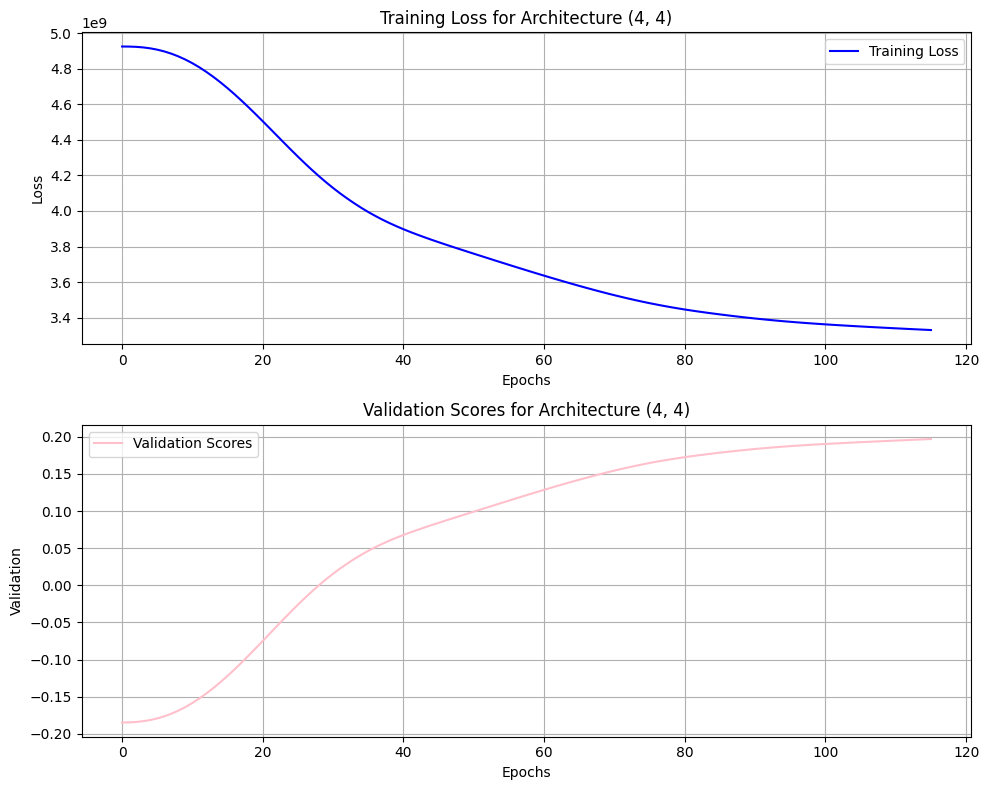

Architecture: (4, 4)
Epochs trained: 116
Train R^2 = 0.1995, MSE = 6568153238.4100, MAE = 40186.7593
Test  R^2 = 0.1971, MSE = 7163318391.6915, MAE = 40896.0376
Generalization gap: 0.0025

Training architecture: (10, 6)


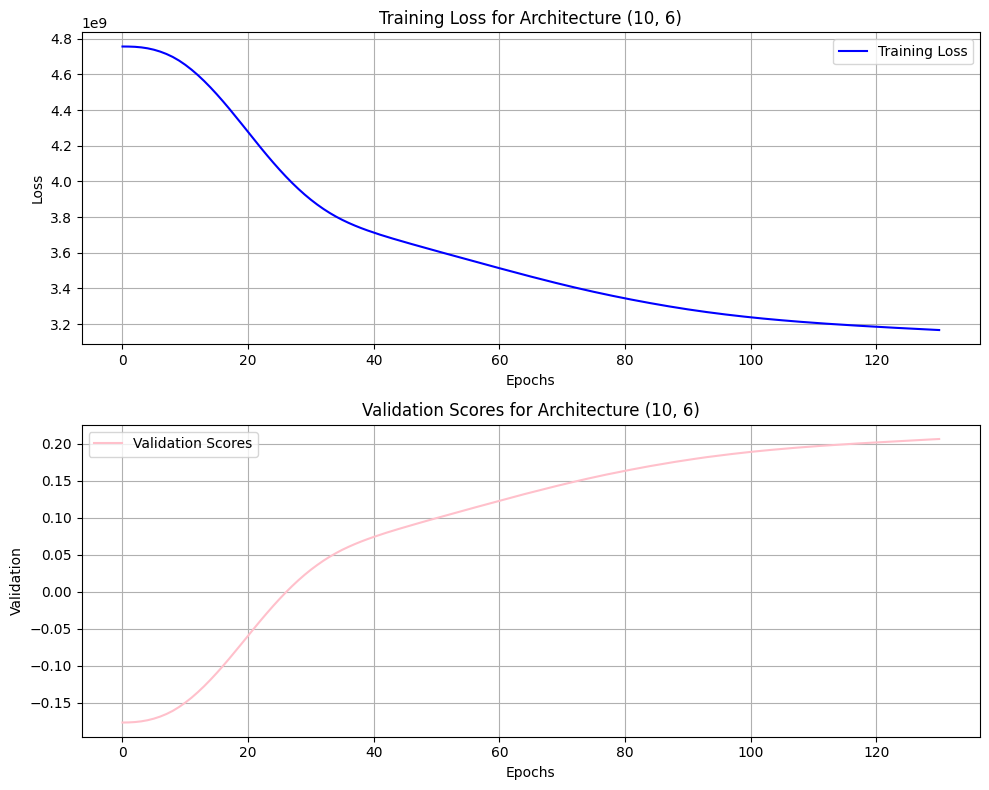

Architecture: (10, 6)
Epochs trained: 131
Train R^2 = 0.2098, MSE = 6483858004.8242, MAE = 37017.3457
Test  R^2 = 0.2077, MSE = 7068274023.9042, MAE = 37760.6247
Generalization gap: 0.0021

Training architecture: (32, 16)


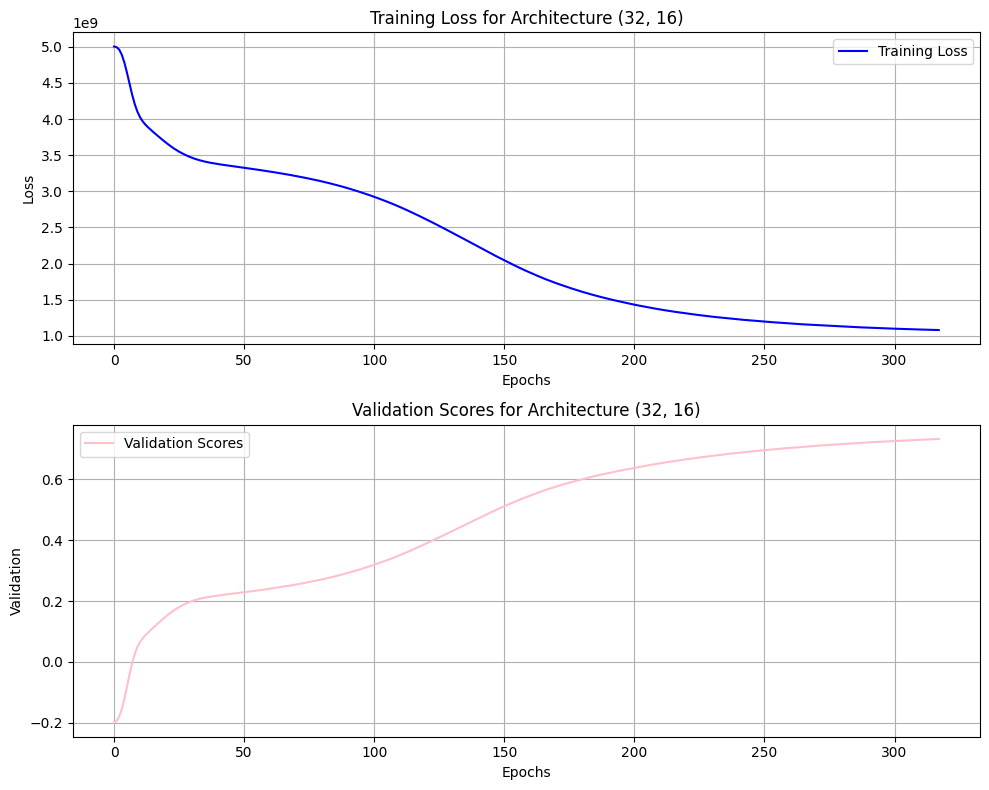

Architecture: (32, 16)
Epochs trained: 318
Train R^2 = 0.7431, MSE = 2108185274.7860, MAE = 23321.5161
Test  R^2 = 0.7499, MSE = 2231276781.2038, MAE = 23748.7229
Generalization gap: 0.0068

Training architecture: (8, 3, 5)


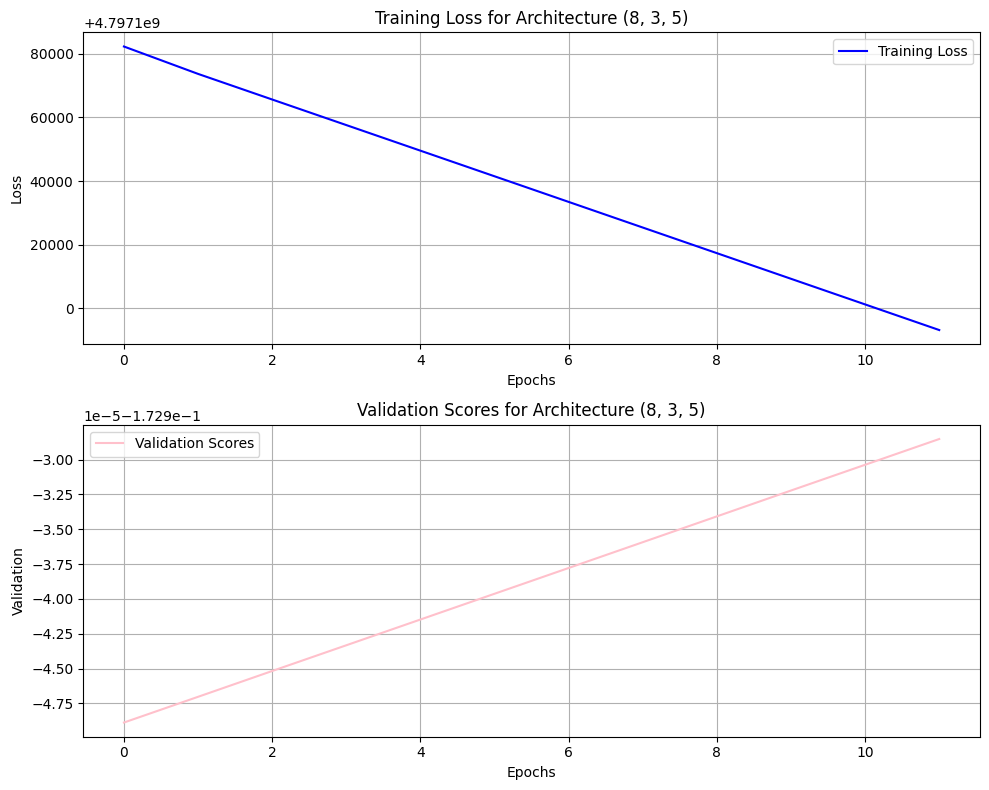

Architecture: (8, 3, 5)
Epochs trained: 12
Train R^2 = -0.1836, MSE = 9711987906.0762, MAE = 38826.5045
Test  R^2 = -0.1771, MSE = 10501706786.1837, MAE = 39762.3877
Generalization gap: 0.0065

Training architecture: (12, 9, 10)


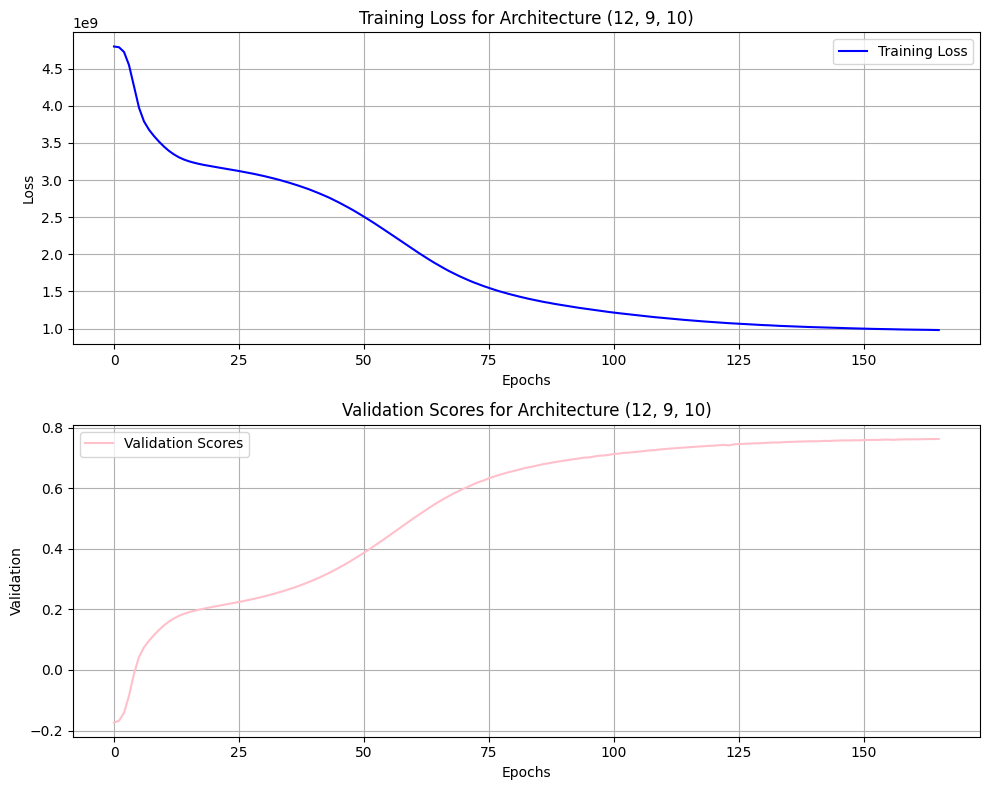

Architecture: (12, 9, 10)
Epochs trained: 166
Train R^2 = 0.7592, MSE = 1975718192.0476, MAE = 21476.6790
Test  R^2 = 0.7648, MSE = 2098743406.2268, MAE = 21872.7085
Generalization gap: 0.0055


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler

X = df
y = y


scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


X_train_full, X_test, y_train_full, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=22222)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=22222)  # 70-30 split


hidden_layers = [(4, 4), (10, 6), (32, 16), (8, 3, 5), (12, 9, 10)]

for h in hidden_layers:
    print(f"\nTraining architecture: {h}")
    model = MLPRegressor(hidden_layer_sizes=h, activation='relu', early_stopping=True, tol=0.0005,
                         validation_fraction=0.2, max_iter=1000, random_state=22222)
    

    model.fit(X_train, y_train)
    
    fig, ax = plt.subplots(2, 1, figsize=(10, 8))
    ax[0].plot(model.loss_curve_, label="Training Loss", color='blue')
    ax[0].set_title(f"Training Loss for Architecture {h}")
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Loss")
    ax[0].legend()
    ax[0].grid(True)
    
    # Plot Validation Scores
    ax[1].plot(model.validation_scores_, label="Validation Scores", color='pink')
    ax[1].set_title(f"Validation Scores for Architecture {h}")
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Validation")
    ax[1].legend()
    ax[1].grid(True)
    
    plt.tight_layout()
    plt.show()

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)


    train_r2 = metrics.r2_score(y_train, y_train_pred)
    test_r2 = metrics.r2_score(y_test, y_test_pred)
    train_mse = metrics.mean_squared_error(y_train, y_train_pred)
    test_mse = metrics.mean_squared_error(y_test, y_test_pred)
    train_mae = metrics.mean_absolute_error(y_train, y_train_pred)
    test_mae = metrics.mean_absolute_error(y_test, y_test_pred)
    generalization_gap = abs(train_r2 - test_r2)

    print(f"Architecture: {h}")
    print(f"Epochs trained: {len(model.loss_curve_)}")
    print(f"Train R^2 = {train_r2:.4f}, MSE = {train_mse:.4f}, MAE = {train_mae:.4f}")
    print(f"Test  R^2 = {test_r2:.4f}, MSE = {test_mse:.4f}, MAE = {test_mae:.4f}")
    print(f"Generalization gap: {generalization_gap:.4f}")